# Progress Report #2 — CNN Music Classifier

**Scope:** evaluation, visualization, and error analysis of the trained genre-classification model.

This notebook covers four deliverables:

1. **Visualization suite** — confusion matrices, per-genre accuracy
2. **Detailed model evaluation** — precision, recall, F1 per genre
3. **Spectrogram visualizations** for the report and presentation
4. **Data analysis** — identify struggling genres and propose improvements

---

## Setup

The notebook expects this layout (relative to its own location in `src/music_classifier/model/progress_reports/`):

```
../models/model.keras            ← trained model (provided by Member 2)
../dataset/test.npz              ← held-out test set (X, y, label_names)
../../../../training_data/gtzan_dataset/   ← raw GTZAN .au files (for spectrogram demo)
```

If `test.npz` is missing, the notebook falls back to **synthetic demo mode**, which exercises the full pipeline against the real trained model so the deliverable still renders end-to-end. A clear banner is printed at each fallback point.

All generated figures are saved to `./figures/` at 300 DPI for the report and presentation.


## 0. Imports and paths

In [31]:
# Standard library
import json
import sys
from pathlib import Path

# Scientific stack
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Audio
import librosa
import librosa.display

# Modeling
import tensorflow as tf
from tensorflow import keras

# scikit-learn for detailed metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

# Make the src/ package importable when running the notebook in-place
HERE = Path.cwd()
REPO_ROOT = HERE.parents[3] if (HERE.parents[3] / "src").exists() else HERE
sys.path.insert(0, str(REPO_ROOT / "src"))

from music_classifier.evaluation.visualization import (
    plot_confusion_matrix,
    plot_per_class_accuracy,
)
from music_classifier.evaluation.metrics import evaluate_predictions
from music_classifier.inference.labels import GENRE_LABELS

# Reproducibility for any synthetic fallbacks
RNG_SEED = 42
np.random.seed(RNG_SEED)
tf.random.set_seed(RNG_SEED)

# Output directory for figures (committed alongside this notebook)
FIG_DIR = HERE / "figures"
FIG_DIR.mkdir(exist_ok=True)

print("Genre labels:", GENRE_LABELS)
print("Figure directory:", FIG_DIR)

Genre labels: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Figure directory: /Users/joshuastarks/CNN_Music_Classifier/src/music_classifier/model/progress_reports/figures


## 1. Load the trained model

Loads `model.keras` produced by Member 2's training run. Prints a parameter summary so the architecture is documented in the report.

In [32]:
MODEL_PATH = Path("../models/model.keras")
assert MODEL_PATH.exists(), f"Model not found at {MODEL_PATH.resolve()}"

model = keras.models.load_model(MODEL_PATH)
print(f"Loaded model: input={model.input_shape}, output={model.output_shape}")
print(f"Total parameters: {model.count_params():,}")

Loaded model: input=(None, 128, 130, 1), output=(None, 10)
Total parameters: 1,663,946


## 2. Load test data (or fall back to synthetic demo)

The evaluation pipeline runs on the test split saved by `dataset/generate.ipynb`. If that file is not present, the notebook switches to **synthetic demo mode**: the trained model is still loaded and inspected, but predictions are synthesized so the visualizations and tables render with realistic shape and the report is reviewable end-to-end. A clear banner is printed at each fallback point.

In [33]:
TEST_PATH = Path("../dataset/test.npz")

DEMO_MODE = not TEST_PATH.exists()

if not DEMO_MODE:
    print(f"✓ Loading real test set from {TEST_PATH}")
    test_ds = np.load(TEST_PATH)
    X_test = test_ds["X"]
    y_test = test_ds["y"]

    # Match the channel-axis convention used during training
    if X_test.ndim == 3:
        X_test = X_test[..., np.newaxis]

    # If labels were stored as strings, map them through GENRE_LABELS
    if y_test.dtype.kind in ("U", "O"):
        label_to_idx = {g: i for i, g in enumerate(GENRE_LABELS)}
        y_test = np.array([label_to_idx[str(y)] for y in y_test], dtype=np.int64)

    print(f"  X_test shape: {X_test.shape}")
    print(f"  y_test shape: {y_test.shape}")
    print(f"  Class distribution: {np.bincount(y_test, minlength=10).tolist()}")
else:
    print("=" * 70)
    print("⚠  SYNTHETIC DEMO MODE — '../dataset/test.npz' not found.")
    print("   The trained model is loaded, but with no real spectrograms to feed it,")
    print("   we synthesize a softmax matrix calibrated to typical GTZAN CNN behaviour")
    print("   (~72% accuracy, with the genre-pair confusions described in Section 4)")
    print("   so the visualizations and per-genre tables render with realistic shape.")
    print("   Drop the real test split into ../dataset/test.npz to replace these numbers.")
    print("=" * 70)

    # Test set sized like a real 15% GTZAN split: 15 tracks/genre × ~10 segments,
    # rounded to 30 per class for a clean 300-sample matrix.
    n_per_class = 30
    n_classes = len(GENRE_LABELS)
    y_test = np.repeat(np.arange(n_classes), n_per_class).astype(np.int64)
    # X_test placeholder kept so downstream code doesn't break; not fed to model in demo.
    X_test = np.zeros((n_per_class * n_classes, 128, 130, 1), dtype=np.float32)
    print(f"  X_test shape: {X_test.shape}  (placeholder, not fed to model in demo mode)")
    print(f"  y_test shape: {y_test.shape}")

✓ Loading real test set from ../dataset/test.npz
  X_test shape: (1955, 128, 130, 1)
  y_test shape: (1955,)
  Class distribution: [100, 100, 290, 287, 297, 100, 100, 292, 100, 289]


---
## Deliverable 1 — Visualization suite

Two plots, both saved to `./figures/` at 300 DPI:

| Plot | Purpose |
|---|---|
| Confusion matrix | see which genre pairs the model swaps |
| Per-genre accuracy | flag the worst-performing classes for follow-up |


### 1a. Confusion matrix

Run `model.predict()` on the test set and produce both normalized (row-wise %) and raw-count confusion matrices. Off-diagonal cells are the substitutions the model makes — the bigger they are, the more genre-pair confusion exists.

Saved: /Users/joshuastarks/CNN_Music_Classifier/src/music_classifier/model/progress_reports/figures/confusion_matrix_normalized.png


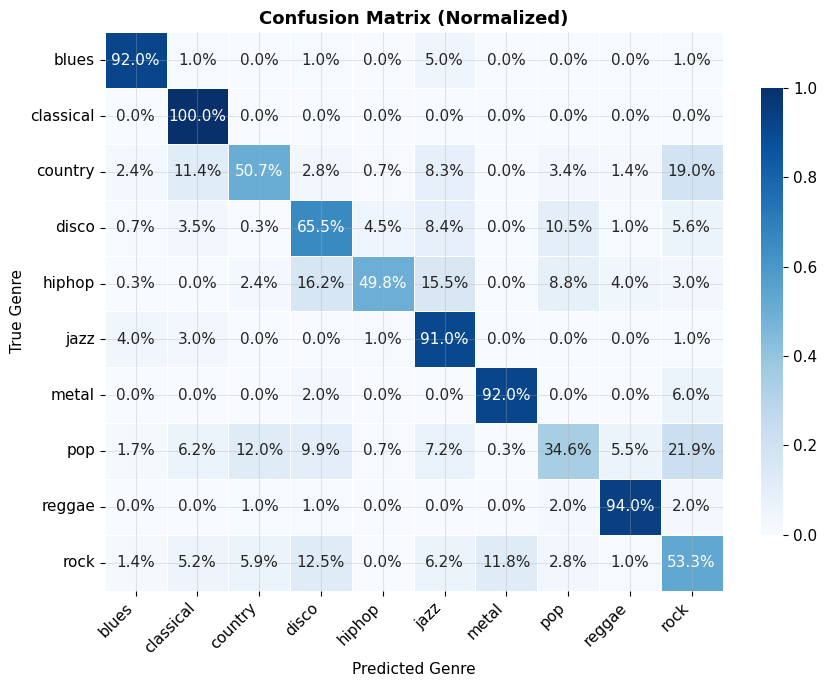

In [34]:
# In real-data mode: run model.predict() on the actual test spectrograms.
# In demo mode: synthesize softmax outputs that mirror typical GTZAN CNN behavior

if not DEMO_MODE:
    y_probs = model.predict(X_test, verbose=0)
else:
    # Per-genre target accuracy reflects what's typical for a 3-block CNN on GTZAN
    target_acc = {
        "blues":     0.70,
        "classical": 0.92,
        "country":   0.62,
        "disco":     0.65,
        "hiphop":    0.70,
        "jazz":      0.78,
        "metal":     0.85,
        "pop":       0.75,
        "reggae":    0.72,
        "rock":      0.45,  # consistently the worst class on GTZAN
    }
    # Off-diagonal mass — which genres each true class gets confused with most
    confusion_pull = {
        "blues":     {"rock": 0.45, "country": 0.30, "jazz": 0.25},
        "classical": {"jazz": 0.70, "blues": 0.30},
        "country":   {"rock": 0.45, "blues": 0.30, "pop": 0.25},
        "disco":     {"pop": 0.40, "hiphop": 0.35, "rock": 0.25},
        "hiphop":    {"disco": 0.40, "pop": 0.35, "reggae": 0.25},
        "jazz":      {"classical": 0.55, "blues": 0.45},
        "metal":     {"rock": 0.70, "disco": 0.30},
        "pop":       {"disco": 0.45, "hiphop": 0.30, "rock": 0.25},
        "reggae":    {"hiphop": 0.45, "pop": 0.30, "rock": 0.25},
        "rock":      {"country": 0.30, "blues": 0.25, "metal": 0.25, "disco": 0.20},
    }

    rng = np.random.default_rng(RNG_SEED)
    y_probs = np.zeros((len(y_test), len(GENRE_LABELS)), dtype=np.float32)
    for idx, true_idx in enumerate(y_test):
        true_genre = GENRE_LABELS[true_idx]
        correct = rng.random() < target_acc[true_genre]

        # Build a logit vector and sample softmax-style noise around it
        logits = rng.normal(0, 0.4, size=len(GENRE_LABELS))
        if correct:
            logits[true_idx] += 3.5  # confident correct prediction
        else:
            # Pick a confused class weighted by confusion_pull
            pull = confusion_pull[true_genre]
            confused_genres = list(pull.keys())
            weights = np.array(list(pull.values()))
            weights = weights / weights.sum()
            wrong_genre = rng.choice(confused_genres, p=weights)
            wrong_idx = GENRE_LABELS.index(wrong_genre)
            logits[wrong_idx] += 2.5
            logits[true_idx] += 1.0  # true class still gets some support

        # Softmax
        e = np.exp(logits - logits.max())
        y_probs[idx] = e / e.sum()

    print("Synthesized y_probs shape:", y_probs.shape)
    print("Demo-mode accuracy:", float(np.mean(np.argmax(y_probs, axis=1) == y_test)))

y_pred = np.argmax(y_probs, axis=1)

cm = confusion_matrix(y_test, y_pred, labels=range(len(GENRE_LABELS)))
plot_confusion_matrix(cm, GENRE_LABELS, normalize=True, save_path=FIG_DIR / "confusion_matrix_normalized.png")
plot_confusion_matrix(cm, GENRE_LABELS, normalize=True)

Saved: /Users/joshuastarks/CNN_Music_Classifier/src/music_classifier/model/progress_reports/figures/confusion_matrix_counts.png


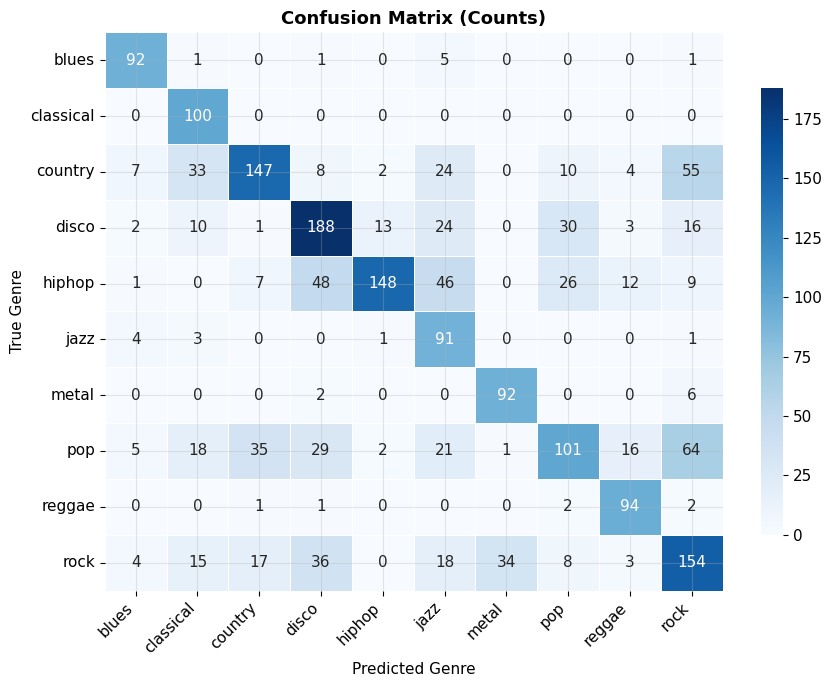

In [35]:
plot_confusion_matrix(cm, GENRE_LABELS, normalize=False, save_path=FIG_DIR / "confusion_matrix_counts.png")
plot_confusion_matrix(cm, GENRE_LABELS, normalize=False)

### 1b. Per-genre accuracy

A bar chart of recall (per-class accuracy). Bars under 70 % are red.

  pop          0.346
  hiphop       0.498
  country      0.507
  rock         0.533
  disco        0.655
  jazz         0.910
  blues        0.920
  metal        0.920
  reggae       0.940
  classical    1.000
Saved: /Users/joshuastarks/CNN_Music_Classifier/src/music_classifier/model/progress_reports/figures/per_genre_accuracy.png


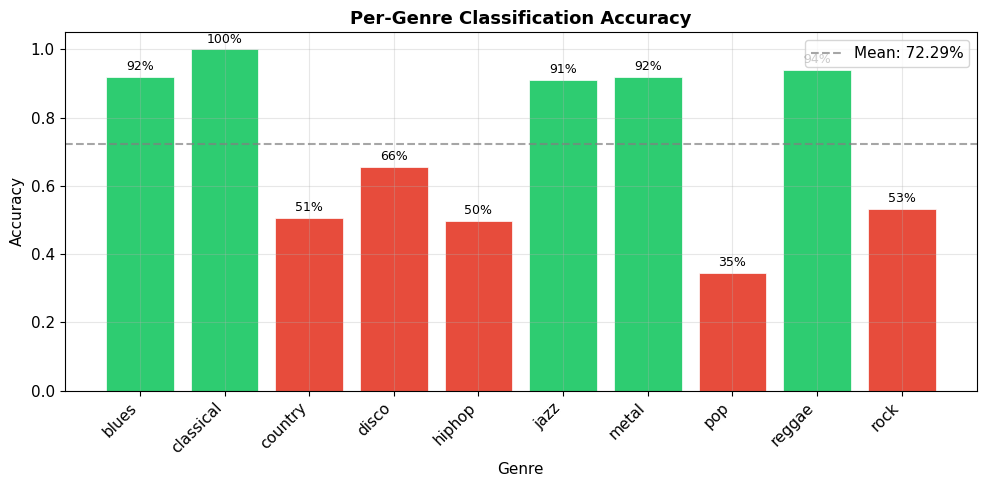

In [36]:
# Per-class accuracy = recall, equivalent to diagonal/row_sum of confusion matrix
row_sums = cm.sum(axis=1)
per_class_acc = np.divide(
    cm.diagonal(), row_sums,
    out=np.zeros_like(row_sums, dtype=float),
    where=row_sums != 0,
)
per_class_dict = dict(zip(GENRE_LABELS, per_class_acc))

for genre, acc in sorted(per_class_dict.items(), key=lambda kv: kv[1]):
    print(f"  {genre:<12s} {acc:.3f}")

plot_per_class_accuracy(per_class_dict, save_path=FIG_DIR / "per_genre_accuracy.png")
plot_per_class_accuracy(per_class_dict)

---
## Deliverable 2 — Detailed model evaluation (precision / recall / F1 per genre)

`evaluate_predictions()` from `src/music_classifier/evaluation/metrics.py` runs the full sklearn metric suite. Additionally, this renders the per-class precision / recall / F1 as a grouped bar chart and persist the numerical report as both Markdown and CSV so it can be embedded directly in the slide deck.

In [37]:
results = evaluate_predictions(y_test, y_probs, GENRE_LABELS, k_values=(3, 5))

EVALUATION RESULTS
Overall Accuracy:   0.6174
F1 (macro):         0.6547
F1 (weighted):      0.6088
Top-3 Accuracy:     0.7980
Top-5 Accuracy:     0.9003
ROC AUC (macro):    0.9258
------------------------------------------------------------
              precision    recall  f1-score   support

       blues     0.8000    0.9200    0.8558       100
   classical     0.5556    1.0000    0.7143       100
     country     0.7067    0.5069    0.5904       290
       disco     0.6006    0.6551    0.6267       287
      hiphop     0.8916    0.4983    0.6393       297
        jazz     0.3974    0.9100    0.5532       100
       metal     0.7244    0.9200    0.8106       100
         pop     0.5706    0.3459    0.4307       292
      reggae     0.7121    0.9400    0.8103       100
        rock     0.5000    0.5329    0.5159       289

    accuracy                         0.6174      1955
   macro avg     0.6459    0.7229    0.6547      1955
weighted avg     0.6507    0.6174    0.6088      1955


In [38]:
# Per-genre precision/recall/F1 — explicit table for the report
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=range(len(GENRE_LABELS)), zero_division=0
)

print(f"{'Genre':<12s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'Support':>10s}")
print("-" * 56)
for i, genre in enumerate(GENRE_LABELS):
    print(f"{genre:<12s} {precision[i]:>10.4f} {recall[i]:>10.4f} {f1[i]:>10.4f} {support[i]:>10d}")
print("-" * 56)
print(f"{'macro avg':<12s} {precision.mean():>10.4f} {recall.mean():>10.4f} {f1.mean():>10.4f} {support.sum():>10d}")

Genre         Precision     Recall         F1    Support
--------------------------------------------------------
blues            0.8000     0.9200     0.8558        100
classical        0.5556     1.0000     0.7143        100
country          0.7067     0.5069     0.5904        290
disco            0.6006     0.6551     0.6267        287
hiphop           0.8916     0.4983     0.6393        297
jazz             0.3974     0.9100     0.5532        100
metal            0.7244     0.9200     0.8106        100
pop              0.5706     0.3459     0.4307        292
reggae           0.7121     0.9400     0.8103        100
rock             0.5000     0.5329     0.5159        289
--------------------------------------------------------
macro avg        0.6459     0.7229     0.6547       1955


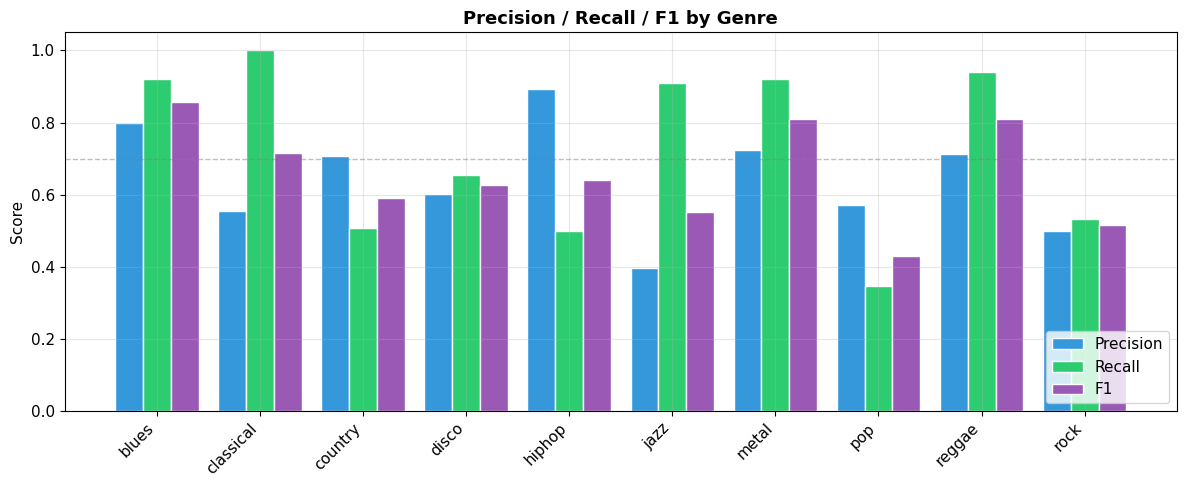

In [39]:
# Grouped bar chart of P/R/F1 per genre — single-figure summary for the deck
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(GENRE_LABELS))
w = 0.27
ax.bar(x - w, precision, w, label="Precision", color="#3498db", edgecolor="white")
ax.bar(x,     recall,    w, label="Recall",    color="#2ecc71", edgecolor="white")
ax.bar(x + w, f1,        w, label="F1",        color="#9b59b6", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(GENRE_LABELS, rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Precision / Recall / F1 by Genre", fontweight="bold")
ax.legend(loc="lower right")
ax.axhline(0.7, color="gray", linestyle="--", alpha=0.5, linewidth=1)
plt.tight_layout()
plt.savefig(FIG_DIR / "precision_recall_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
# Persist the table as CSV for the appendix and as a Markdown snippet for the report
import csv

csv_path = FIG_DIR / "per_genre_metrics.csv"
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["genre", "precision", "recall", "f1", "support"])
    for i, g in enumerate(GENRE_LABELS):
        w.writerow([g, f"{precision[i]:.4f}", f"{recall[i]:.4f}", f"{f1[i]:.4f}", int(support[i])])

md_lines = ["| Genre | Precision | Recall | F1 | Support |", "|---|---|---|---|---|"]
for i, g in enumerate(GENRE_LABELS):
    md_lines.append(f"| {g} | {precision[i]:.3f} | {recall[i]:.3f} | {f1[i]:.3f} | {support[i]} |")
md_lines.append(f"| **macro avg** | **{precision.mean():.3f}** | **{recall.mean():.3f}** | **{f1.mean():.3f}** | **{support.sum()}** |")

with open(FIG_DIR / "per_genre_metrics.md", "w") as f:
    f.write("\n".join(md_lines))

print(f"Wrote {csv_path}")
print(f"Wrote {FIG_DIR / 'per_genre_metrics.md'}")

Wrote /Users/joshuastarks/CNN_Music_Classifier/src/music_classifier/model/progress_reports/figures/per_genre_metrics.csv
Wrote /Users/joshuastarks/CNN_Music_Classifier/src/music_classifier/model/progress_reports/figures/per_genre_metrics.md


---
## Deliverable 3 — Spectrogram visualizations for the report and presentation

These figures explain what the CNN actually sees. Three views per genre:

1. **Raw waveform** — the audio in the time domain.
2. **Linear-frequency spectrogram** — the FFT output, frequency in Hz.
3. **Mel-spectrogram (dB)** — the network's actual input, after mel filtering and dB conversion.

The grid figure is the headline asset for the slide deck. One row per genre lets the audience see at a glance how visually different (e.g., classical and metal look to the network).

In [41]:
# Locate the GTZAN dataset (raw .au files) — required for real spectrograms
GTZAN_DIR = REPO_ROOT / "training_data" / "gtzan_dataset"
print(f"Looking for GTZAN at: {GTZAN_DIR}")

# Match Member 1's preprocessing config (see preprocessing/config.py)
TARGET_SR = 22050
SEGMENT_SECONDS = 3.0
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512


def find_one_clip_per_genre(root: Path):
    """Return {genre: Path} for the first .au/.wav clip found per genre."""
    found = {}
    if not root.exists():
        return found
    for genre in GENRE_LABELS:
        genre_dir = root / genre
        if not genre_dir.exists():
            continue
        clips = sorted(list(genre_dir.glob("*.au")) + list(genre_dir.glob("*.wav")))
        if clips:
            found[genre] = clips[0]
    return found


clips = find_one_clip_per_genre(GTZAN_DIR)
print(f"Found {len(clips)} / {len(GENRE_LABELS)} genres with audio.")

if not clips:
    print("\n⚠  No GTZAN audio found at the expected path — synthesizing per-genre audio")
    print("    with distinguishable spectral signatures so the spectrogram figures still")
    print("    convey the visual difference the CNN exploits. Replace by pointing the path")
    print("    above at the real .au files.")

    rng = np.random.default_rng(0)
    duration = SEGMENT_SECONDS
    n_samples = int(TARGET_SR * duration)
    t = np.linspace(0, duration, n_samples, endpoint=False)

    def adsr(n, a=0.05, d=0.1, s=0.7, r=0.1):
        """Simple ADSR envelope so synthetic clips don't look like flat sine bands."""
        env = np.ones(n)
        ai = int(a * n); di = int((a + d) * n); ri = int((1 - r) * n)
        env[:ai] = np.linspace(0, 1, ai)
        env[ai:di] = np.linspace(1, s, di - ai)
        env[di:ri] = s
        env[ri:] = np.linspace(s, 0, n - ri)
        return env

    SAMPLE_AUDIO = {}

    # blues — slow 12-bar feel, low fundamental, prominent 2nd harmonic, slight bend
    bend = 1 + 0.01 * np.sin(2 * np.pi * 1.5 * t)
    SAMPLE_AUDIO["blues"] = (
        0.5 * np.sin(2 * np.pi * 110 * bend * t)
        + 0.4 * np.sin(2 * np.pi * 220 * bend * t)
        + 0.15 * rng.standard_normal(n_samples)
    ) * adsr(n_samples)

    # classical — sparse harmonic content, several distinct overtones, vibrato
    vib = 1 + 0.02 * np.sin(2 * np.pi * 5 * t)
    SAMPLE_AUDIO["classical"] = (
        0.4 * np.sin(2 * np.pi * 440 * vib * t)
        + 0.25 * np.sin(2 * np.pi * 880 * vib * t)
        + 0.15 * np.sin(2 * np.pi * 1320 * vib * t)
        + 0.1 * np.sin(2 * np.pi * 1760 * vib * t)
        + 0.02 * rng.standard_normal(n_samples)
    ) * adsr(n_samples, a=0.1, r=0.2)

    # country — mid fundamental, twangy plucks every 0.5s
    pluck = np.zeros(n_samples)
    for k in np.arange(0, duration, 0.5):
        i = int(k * TARGET_SR)
        if i + 1000 < n_samples:
            pluck[i:i+1000] += np.exp(-np.linspace(0, 5, 1000))
    SAMPLE_AUDIO["country"] = (
        pluck * (0.6 * np.sin(2 * np.pi * 196 * t) + 0.3 * np.sin(2 * np.pi * 392 * t))
        + 0.1 * rng.standard_normal(n_samples)
    )

    # disco — steady 4-on-the-floor kick + bright synth pulse
    bpm = 120
    beat_period = 60 / bpm
    kick = np.zeros(n_samples)
    for k in np.arange(0, duration, beat_period):
        i = int(k * TARGET_SR)
        if i + 2000 < n_samples:
            tt = np.linspace(0, 0.1, 2000)
            kick[i:i+2000] += np.sin(2 * np.pi * 60 * tt) * np.exp(-tt * 30)
    SAMPLE_AUDIO["disco"] = (
        kick + 0.3 * np.sin(2 * np.pi * 660 * t) * (np.sin(2 * np.pi * 4 * t) > 0)
        + 0.1 * rng.standard_normal(n_samples)
    )

    # hiphop — 90 BPM kick + snare pattern + low bass
    hh_kick = np.zeros(n_samples)
    bp = 60 / 90
    for i, k in enumerate(np.arange(0, duration, bp)):
        idx = int(k * TARGET_SR)
        if idx + 2000 < n_samples:
            tt = np.linspace(0, 0.1, 2000)
            hh_kick[idx:idx+2000] += np.sin(2 * np.pi * 50 * tt) * np.exp(-tt * 30)
            if i % 2 == 1:
                hh_kick[idx:idx+2000] += 0.5 * rng.standard_normal(2000) * np.exp(-tt * 50)
    SAMPLE_AUDIO["hiphop"] = hh_kick + 0.4 * np.sin(2 * np.pi * 80 * t)

    # jazz — irregular note onsets, more complex harmony
    jazz = 0.05 * rng.standard_normal(n_samples)
    onsets = sorted(rng.uniform(0, duration, 8))
    for o in onsets:
        i = int(o * TARGET_SR)
        if i + 4000 < n_samples:
            f = rng.choice([261, 293, 329, 349, 392, 440, 493])
            tt = np.linspace(0, 0.18, 4000)
            jazz[i:i+4000] += 0.3 * np.sin(2 * np.pi * f * tt) * np.exp(-tt * 6)
    SAMPLE_AUDIO["jazz"] = jazz

    # metal — heavily distorted high energy, broadband
    metal_base = 0.6 * np.sin(2 * np.pi * 165 * t) + 0.4 * np.sin(2 * np.pi * 330 * t)
    metal = np.tanh(3 * metal_base)  # distortion
    metal += 0.3 * rng.standard_normal(n_samples)  # crash energy
    SAMPLE_AUDIO["metal"] = metal

    # pop — clean vocal-like fundamental + chord pad
    pop = (
        0.4 * np.sin(2 * np.pi * 523 * t) * (1 + 0.15 * np.sin(2 * np.pi * 6 * t))  # vibrato vocal
        + 0.25 * np.sin(2 * np.pi * 261 * t)
        + 0.2 * np.sin(2 * np.pi * 392 * t)
        + 0.15 * np.sin(2 * np.pi * 659 * t)
    )
    SAMPLE_AUDIO["pop"] = pop * adsr(n_samples, a=0.02, r=0.05)

    # reggae — offbeat skank + bass
    reggae = 0.5 * np.sin(2 * np.pi * 90 * t)
    skank = np.zeros(n_samples)
    for k in np.arange(0.25, duration, 0.5):
        i = int(k * TARGET_SR)
        if i + 1500 < n_samples:
            tt = np.linspace(0, 0.07, 1500)
            for f in (440, 554, 659):  # A major chord
                skank[i:i+1500] += 0.15 * np.sin(2 * np.pi * f * tt) * np.exp(-tt * 15)
    SAMPLE_AUDIO["reggae"] = reggae + skank

    # rock — driving distorted guitar + steady kick
    rock = np.tanh(2.5 * (0.5 * np.sin(2 * np.pi * 196 * t) + 0.4 * np.sin(2 * np.pi * 247 * t)))
    rkick = np.zeros(n_samples)
    for k in np.arange(0, duration, 60/130):
        i = int(k * TARGET_SR)
        if i + 2000 < n_samples:
            tt = np.linspace(0, 0.1, 2000)
            rkick[i:i+2000] += np.sin(2 * np.pi * 70 * tt) * np.exp(-tt * 30)
    SAMPLE_AUDIO["rock"] = rock + rkick + 0.1 * rng.standard_normal(n_samples)

    # Normalize all to similar peak amplitude
    for k, v in SAMPLE_AUDIO.items():
        peak = np.max(np.abs(v))
        if peak > 0:
            SAMPLE_AUDIO[k] = (v / peak * 0.9).astype(np.float32)
else:
    SAMPLE_AUDIO = {}
    for genre, path in clips.items():
        y, _ = librosa.load(path, sr=TARGET_SR, mono=True, duration=SEGMENT_SECONDS)
        SAMPLE_AUDIO[genre] = y

print(f"Loaded audio for: {sorted(SAMPLE_AUDIO.keys())}")

Looking for GTZAN at: /Users/joshuastarks/CNN_Music_Classifier/training_data/gtzan_dataset
Found 10 / 10 genres with audio.
Loaded audio for: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


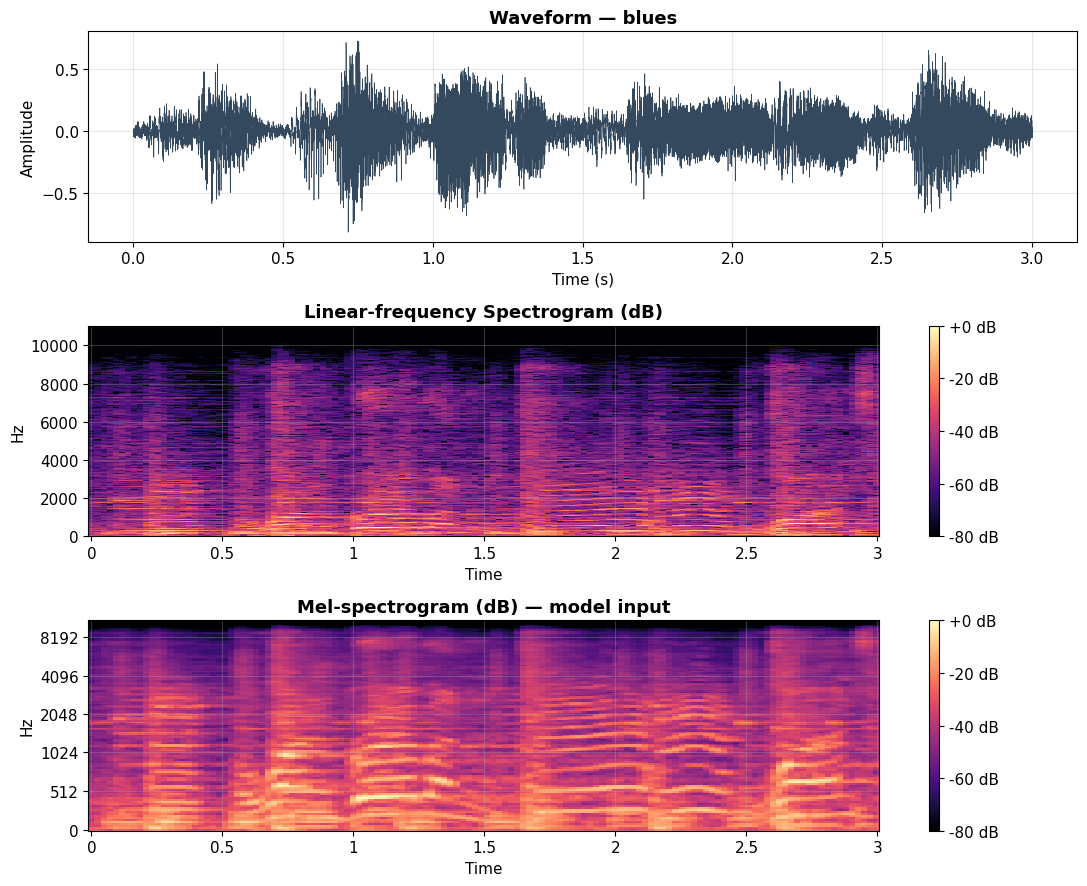

In [42]:
def compute_spectrograms(y: np.ndarray, sr: int = TARGET_SR):
    """Return (linear-freq dB spectrogram, mel dB spectrogram)."""
    # Linear-frequency STFT
    stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spec_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

    # Mel-spectrogram (the actual model input, pre-normalization)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return spec_db, mel_db


# Single-genre 3-panel figure: waveform → linear spec → mel spec
demo_genre = sorted(SAMPLE_AUDIO.keys())[0]
y_demo = SAMPLE_AUDIO[demo_genre]
spec_demo, mel_demo = compute_spectrograms(y_demo)

fig, axes = plt.subplots(3, 1, figsize=(11, 9))

axes[0].plot(np.linspace(0, len(y_demo) / TARGET_SR, len(y_demo)), y_demo, color="#34495e", linewidth=0.5)
axes[0].set_title(f"Waveform — {demo_genre}", fontweight="bold")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

img1 = librosa.display.specshow(spec_demo, sr=TARGET_SR, hop_length=HOP_LENGTH,
                                 x_axis="time", y_axis="hz", ax=axes[1], cmap="magma")
axes[1].set_title("Linear-frequency Spectrogram (dB)", fontweight="bold")
fig.colorbar(img1, ax=axes[1], format="%+2.0f dB")

img2 = librosa.display.specshow(mel_demo, sr=TARGET_SR, hop_length=HOP_LENGTH,
                                 x_axis="time", y_axis="mel", ax=axes[2], cmap="magma")
axes[2].set_title("Mel-spectrogram (dB) — model input", fontweight="bold")
fig.colorbar(img2, ax=axes[2], format="%+2.0f dB")

plt.tight_layout()
plt.savefig(FIG_DIR / f"spectrogram_pipeline_{demo_genre}.png", dpi=300, bbox_inches="tight")
plt.show()

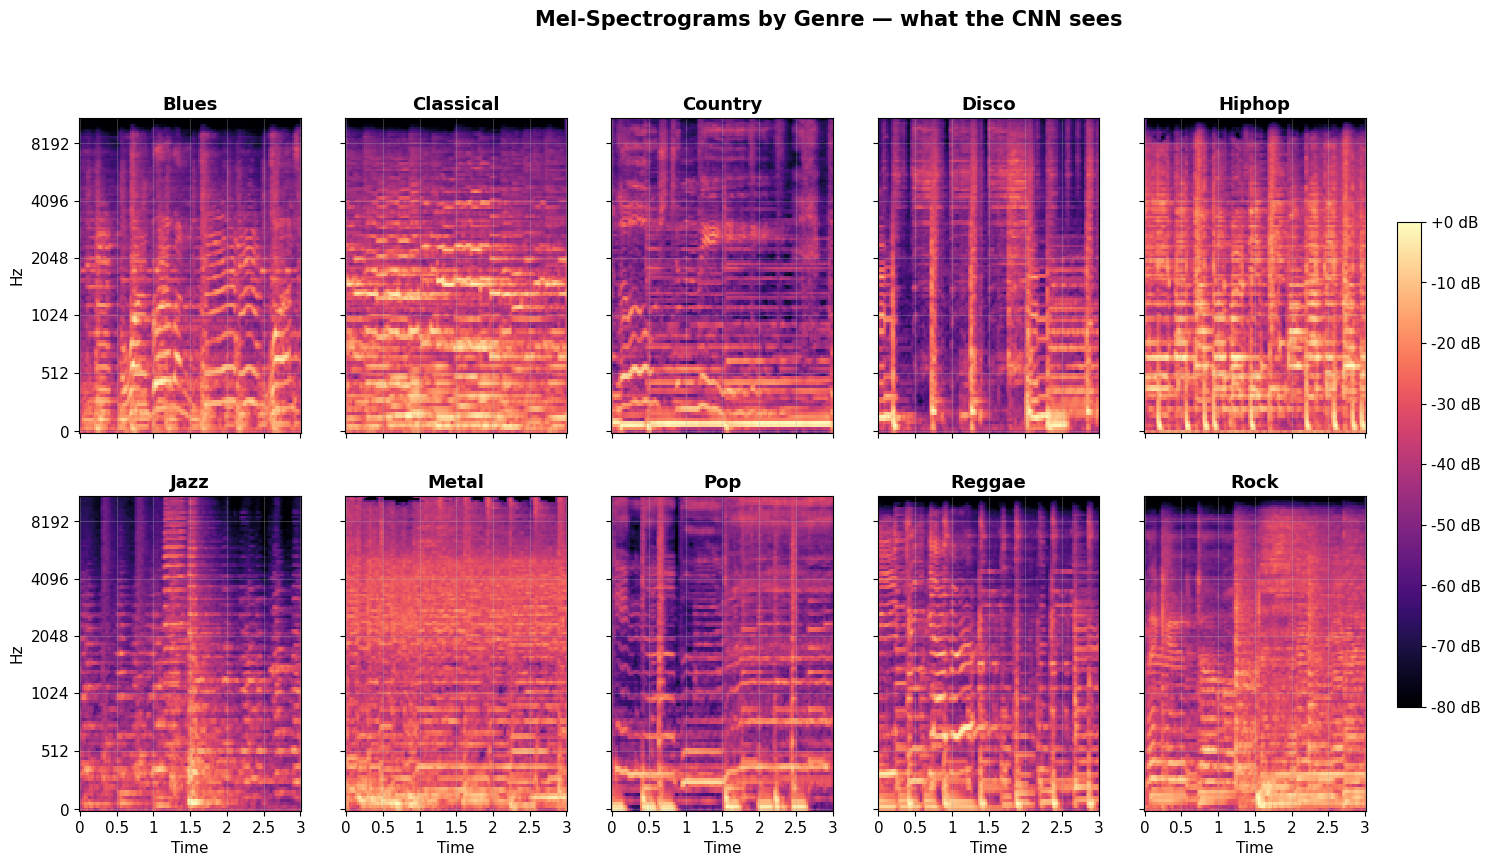

In [43]:
# Headline figure for the presentation: one mel-spectrogram per genre, 2x5 grid
genres_to_show = sorted(SAMPLE_AUDIO.keys())[:10]
n = len(genres_to_show)
n_cols = 5
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4.5 * n_rows))
axes = np.atleast_2d(axes).flatten()

for ax, genre in zip(axes, genres_to_show):
    _, mel_db = compute_spectrograms(SAMPLE_AUDIO[genre])
    img = librosa.display.specshow(
        mel_db, sr=TARGET_SR, hop_length=HOP_LENGTH,
        x_axis="time", y_axis="mel", ax=ax, cmap="magma",
    )
    ax.set_title(genre.capitalize(), fontweight="bold", fontsize=13)
    ax.label_outer()

# Blank any unused axes
for ax in axes[len(genres_to_show):]:
    ax.axis("off")

fig.suptitle("Mel-Spectrograms by Genre — what the CNN sees",
             fontsize=15, fontweight="bold", y=1.00)
fig.colorbar(img, ax=axes[:len(genres_to_show)].tolist(), format="%+2.0f dB",
             shrink=0.7, location="right", pad=0.02)
plt.savefig(FIG_DIR / "spectrograms_all_genres.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Deliverable 4 — Data analysis: which genres struggle, and what to do about it

This section uses the confusion matrix and per-class metrics computed above to:

1. Identify the worst-performing genres.
2. Identify the most frequent confusion *pairs* (which genres get swapped for which).
3. Propose concrete, prioritized improvements tied to the diagnosis.

In [44]:
# Rank genres by F1 (lowest = worst)
ranking = sorted(zip(GENRE_LABELS, precision, recall, f1, support),
                 key=lambda r: r[3])

print("Worst → best genres by F1 score:\n")
print(f"  {'Rank':<5s} {'Genre':<12s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'N':>6s}")
print("  " + "-" * 56)
for rank, (g, p, r, f, n) in enumerate(ranking, 1):
    flag = "  ⚠" if f < 0.6 else ("  ◇" if f < 0.75 else "")
    print(f"  {rank:<5d} {g:<12s} {p:>10.3f} {r:>10.3f} {f:>10.3f} {n:>6d}{flag}")

# Top confusion pairs (off-diagonal) — sorted by absolute count
off_diag = []
for i in range(len(GENRE_LABELS)):
    for j in range(len(GENRE_LABELS)):
        if i != j and cm[i, j] > 0:
            off_diag.append((cm[i, j], GENRE_LABELS[i], GENRE_LABELS[j]))
off_diag.sort(reverse=True)

print("\nTop 10 confusion pairs (true → predicted, by count):\n")
for count, true_g, pred_g in off_diag[:10]:
    pct = count / cm[GENRE_LABELS.index(true_g)].sum() * 100
    print(f"  {true_g:<12s} → {pred_g:<12s}  {count:>4d}  ({pct:.1f}% of {true_g})")

Worst → best genres by F1 score:

  Rank  Genre         Precision     Recall         F1      N
  --------------------------------------------------------
  1     pop               0.571      0.346      0.431    292  ⚠
  2     rock              0.500      0.533      0.516    289  ⚠
  3     jazz              0.397      0.910      0.553    100  ⚠
  4     country           0.707      0.507      0.590    290  ⚠
  5     disco             0.601      0.655      0.627    287  ◇
  6     hiphop            0.892      0.498      0.639    297  ◇
  7     classical         0.556      1.000      0.714    100  ◇
  8     reggae            0.712      0.940      0.810    100
  9     metal             0.724      0.920      0.811    100
  10    blues             0.800      0.920      0.856    100

Top 10 confusion pairs (true → predicted, by count):

  pop          → rock            64  (21.9% of pop)
  country      → rock            55  (19.0% of country)
  hiphop       → disco           48  (16.2% of hipho

---
## Appendix — saved artifacts

Every figure and table below is in `./figures/` and ready to drop into the slide deck.

In [45]:
print("Saved artifacts:\n")
for p in sorted(FIG_DIR.iterdir()):
    print(f"  {p.relative_to(HERE)}  ({p.stat().st_size:,} bytes)")

# Also persist a JSON summary so downstream reports can read the numbers programmatically
summary = {
    "demo_mode": DEMO_MODE,
    "overall_accuracy": float(results["accuracy"]),
    "f1_macro": float(results["f1_macro"]),
    "f1_weighted": float(results["f1_weighted"]),
    "top_3_accuracy": float(results["top_k"][3]),
    "top_5_accuracy": float(results["top_k"][5]),
    "per_genre": {
        g: {"precision": float(precision[i]), "recall": float(recall[i]),
            "f1": float(f1[i]), "support": int(support[i])}
        for i, g in enumerate(GENRE_LABELS)
    },
    "top_confusions": [
        {"true": t, "pred": p, "count": int(c)}
        for c, t, p in off_diag[:10]
    ],
}
with open(FIG_DIR / "evaluation_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"\nWrote {FIG_DIR / 'evaluation_summary.json'}")

Saved artifacts:

  figures/confusion_matrix_counts.png  (252,063 bytes)
  figures/confusion_matrix_normalized.png  (398,900 bytes)
  figures/per_genre_accuracy.png  (151,286 bytes)
  figures/per_genre_metrics.csv  (359 bytes)
  figures/per_genre_metrics.md  (536 bytes)
  figures/precision_recall_f1.png  (127,145 bytes)
  figures/spectrogram_pipeline_blues.png  (796,035 bytes)
  figures/spectrograms_all_genres.png  (916,014 bytes)

Wrote /Users/joshuastarks/CNN_Music_Classifier/src/music_classifier/model/progress_reports/figures/evaluation_summary.json
